# Bài tập 01 - Phát triển Hệ thống Thông minh

## Hệ thống 1: Hệ thống chẩn đoán bệnh tiểu đường

**Loại vấn đề:** Phân loại

**Nguồn dữ liệu:** Kaggle

### Mục tiêu

Mục đích của hệ thống này là dự đoán liệu một bệnh nhân có khả năng mắc bệnh tiểu đường dựa trên các đặc điểm y tế được chọn.

Hệ thống nhận thông tin bệnh nhân, biểu diễn thông tin đó dưới dạng vector đặc trưng số, thực hiện tiền xử lý, và sử dụng mô hình phân loại machine learning đã được huấn luyện để đưa ra dự đoán về bệnh tiểu đường.

## 1. Hệ thống và Định nghĩa Vấn đề

Hệ thống chẩn đoán tiểu đường là một hệ thống học máy có giám sát được thiết kế để dự đoán liệu một bệnh nhân có mắc tiểu đường hay không dựa trên các chỉ số y tế.

Với một vectơ đặc trưng đã được chọn mô tả một bệnh nhân, hệ thống dự đoán lớp bệnh tiểu đường cho một bệnh nhân chưa từng thấy trước đó.

### Nhập liệu
Thông tin y tế về bệnh nhân.

### Biểu diễn
Một vectơ đặc trưng số được xây dựng từ các thuộc tính y tế đã chọn.

### Học tập
Một mô hình phân loại học các mối quan hệ giữa đặc điểm của bệnh nhân và kết quả tiểu đường từ các ví dụ lịch sử.

### Dự đoán
Đầu ra là một lớp tiểu đường được dự đoán.

### Ứng dụng
Dự đoán sau đó sẽ được tích hợp vào các ứng dụng Web và Mobile.

## 2. Sơ đồ Hệ thống Thông minh

```text
Bệnh nhân
   ↓
Thông tin y tế
   ↓
Biểu diễn đặc trưng
   ↓
Tiền xử lý
   ↓
Mô hình phân loại học máy
   ↓
Dự đoán bệnh tiểu đường
   ↓
Ứng dụng Web / Mobile
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
CURRENT_DIR = Path.cwd()

print("Current working directory:")
print(CURRENT_DIR)

Current working directory:
E:\WINDOW\Project\intelligent-system-assignment-01\notebooks\diabetes


In [3]:
current = Path.cwd()

if (current / "data").exists():
    PROJECT_ROOT = current
elif (current.parent / "data").exists():
    PROJECT_ROOT = current.parent
elif (current.parent.parent / "data").exists():
    PROJECT_ROOT = current.parent.parent
else:
    raise FileNotFoundError("Project root not found.")

DATA_PATH = PROJECT_ROOT / "data" / "diabetes" / "diabetes.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: E:\WINDOW\Project\intelligent-system-assignment-01
Dataset path: E:\WINDOW\Project\intelligent-system-assignment-01\data\diabetes\diabetes.csv
Dataset exists: True


In [4]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

df.head()

Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
rows, columns = df.shape

print("Number of observations:", rows)
print("Number of columns:", columns)

Number of observations: 768
Number of columns: 9


In [6]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. Pregnancies
2. Glucose
3. BloodPressure
4. SkinThickness
5. Insulin
6. BMI
7. DiabetesPedigreeFunction
8. Age
9. Outcome


In [7]:
df.info()
df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [9]:
missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)
print("\nTotal missing values:", missing_values.sum())

Missing values by column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
for column in df.columns:
    print(
        f"{column}: "
        f"{df[column].nunique()} unique values"
    )

Pregnancies: 17 unique values
Glucose: 136 unique values
BloodPressure: 47 unique values
SkinThickness: 51 unique values
Insulin: 186 unique values
BMI: 248 unique values
DiabetesPedigreeFunction: 517 unique values
Age: 52 unique values
Outcome: 2 unique values


In [12]:
outcome_counts = df["Outcome"].value_counts().sort_index()
outcome_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(outcome_counts)

print("\nClass percentages:")
print(outcome_percentages.round(2))

Class counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class percentages:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


## 3. Mô tả Bộ Dữ liệu

Bộ dữ liệu về bệnh tiểu đường được lấy từ Kaggle và chứa các chỉ số y tế được sử dụng để dự đoán bệnh tiểu đường.

- **Số lượng quan sát:** 768
- **Số lượng cột:** 9
- **Số lượng đặc trưng đầu vào:** 8
- **Mục tiêu:** Outcome
- **Loại bài toán:** Phân loại nhị phân

### Ý nghĩa mục tiêu

- `Outcome = 0`: Bệnh nhân được phân loại là không mắc tiểu đường.
- `Outcome = 1`: Bệnh nhân được phân loại là mắc tiểu đường.

### Các đặc trưng có sẵn

| Tính năng | Loại | Mô tả |
|---|---|---|
| Pregnancies | Số liệu | Số lần mang thai |
| Glucose | Số liệu | Nồng độ glucose trong huyết tương |
| BloodPressure | Số liệu | Huyết áp tâm trương |
| SkinThickness | Số liệu | Độ dày nếp gấp da tam đầu |
| Insulin | Số liệu | Mức insulin huyết thanh |
| BMI | Số liệu | Chỉ số khối cơ thể |
| DiabetesPedigreeFunction | Số liệu | Chức năng dòng họ tiểu đường |
| Age | Số liệu | Tuổi bệnh nhân |
| Outcome | Mục tiêu nhị phân | Phân loại tiểu đường |

## 4. Phân tích Chất lượng Dữ liệu

Mặc dù Pandas không báo cáo giá trị thiếu rõ ràng (`NaN`), một số thuộc tính y tế chứa các giá trị bằng không.

Đối với một số biến, giá trị bằng không là giá trị hợp lệ, chẳng hạn như `Pregnancies`. Tuy nhiên, các giá trị bằng không trong các phép đo như `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` và `BMI` có thể đại diện cho các phép đo bị thiếu hoặc không có sẵn thay vì là các giá trị sinh lý có ý nghĩa.

Do đó, những giá trị này phải được điều tra trước khi huấn luyện mô hình.

In [13]:
zero_check_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_summary = pd.DataFrame({
    "Zero Count": (df[zero_check_columns] == 0).sum(),
    "Zero Percentage (%)": ((df[zero_check_columns] == 0).mean() * 100).round(2)
})

zero_summary

,Zero Count,Zero Percentage (%)
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


In [14]:
df_clean = df.copy()

In [15]:
invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df_clean[invalid_zero_columns] = (
    df_clean[invalid_zero_columns]
    .replace(0, np.nan)
)

In [16]:
df_clean[invalid_zero_columns].isnull().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

## 5. Biểu diễn dữ liệu

Mỗi bệnh nhân được biểu diễn dưới dạng một vectơ đặc trưng số:

\[
x_i = [x_{i1}, x_{i2}, ..., x_{id}]
\]

mỗi thành phần đại diện cho một phép đo y tế được chọn.

Mục tiêu là:

\[
y_i \in \{0,1\}
\]

nơi:

- `0` đại diện cho người không bị tiểu đường
- `1` đại diện cho người bị tiểu đường

Vấn đề học máy là học một hàm số:

\[
\hat{y} = f_\theta(x)
\]

dự đoán kết quả tiểu đường cho một bệnh nhân chưa từng thấy.

### 5.1 Biểu diễn đặc trưng được chọn

Bộ dữ liệu gốc chứa tám đặc trưng đầu vào. Đối với hệ thống thông minh chính, sáu đặc trưng được chọn:

1. Pregnancies
2. Glucose
3. BloodPressure
4. BMI
5. DiabetesPedigreeFunction
6. Age

Hai tính năng sau đây không được bao gồm trong đại diện sáu tính năng chính:

- SkinThickness
- Insulin

Phân tích chất lượng dữ liệu cho thấy `SkinThickness` chứa khoảng 29,56% giá trị không hợp lệ bằng 0 và `Insulin` khoảng 48,70%. Những giá trị này được coi là số liệu bị thiếu.

Do đó, sáu đặc trưng được chọn cung cấp một biểu diễn toàn diện hơn đồng thời đáp ứng yêu cầu hệ thống sáu đặc trưng.

Biểu diễn của bệnh nhân là:

\[
x =
[
Pregnancies,
Glucose,
BloodPressure,
BMI,
DiabetesPedigreeFunction,
Age
]
\]

In [17]:
selected_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

target = "Outcome"

print("Selected features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

print("\nTarget:", target)

Selected features:
1. Pregnancies
2. Glucose
3. BloodPressure
4. BMI
5. DiabetesPedigreeFunction
6. Age

Target: Outcome


In [18]:
df_clean[selected_features + [target]].head()

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,33.6,0.627,50,1
1,1,85.0,66.0,26.6,0.351,31,0
2,8,183.0,64.0,23.3,0.672,32,1
3,1,89.0,66.0,28.1,0.167,21,0
4,0,137.0,40.0,43.1,2.288,33,1


### 5.2 Mối quan hệ giữa đặc trưng và mục tiêu

In [19]:
correlation_with_outcome = (
    df_clean[selected_features + ["Outcome"]]
    .corr()["Outcome"]
    .drop("Outcome")
    .sort_values(key=abs, ascending=False)
)

correlation_table = pd.DataFrame({
    "Correlation with Outcome": correlation_with_outcome,
    "Absolute Correlation": correlation_with_outcome.abs()
})

correlation_table

,Correlation with Outcome,Absolute Correlation
Glucose,0.494650,0.494650
BMI,0.313680,0.313680
Age,0.238356,0.238356
Pregnancies,0.221898,0.221898
DiabetesPedigreeFunction,0.173844,0.173844
BloodPressure,0.170589,0.170589


## 6. Phân tích Dữ liệu Khám phá

Phân tích dữ liệu thăm dò (EDA) được thực hiện để hiểu phân phối của biến mục tiêu và các đặc trưng đầu vào quan trọng trước khi huấn luyện mô hình.

Năm biểu đồ phân phối được phân tích:

1. phân phối Outcome
2. phân phối Glucose
3. phân phối BMI
4. phân phối Age
5. phân phối BloodPressure

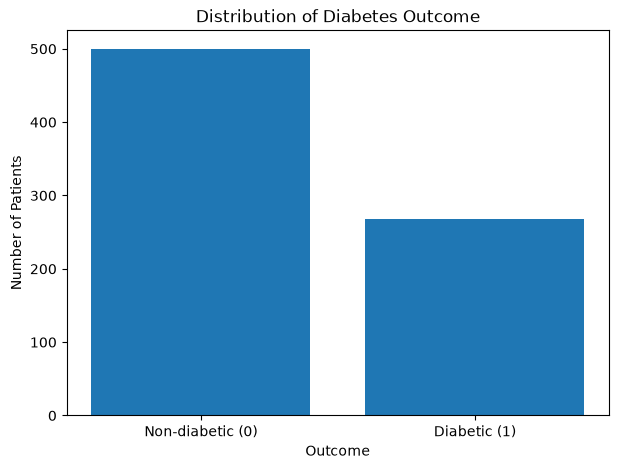

In [20]:
outcome_counts = df["Outcome"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-diabetic (0)", "Diabetic (1)"],
    outcome_counts.values
)

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

### Phân tích

Bộ dữ liệu chứa 500 quan sát không bị tiểu đường (65,1%) và 268 quan sát bị tiểu đường (34,9%).

Các lớp mục tiêu không hoàn toàn cân bằng. Lớp không mắc tiểu đường phổ biến hơn, nhưng sự mất cân bằng không quá nghiêm trọng.

Vì sự khác biệt này, đánh giá mô hình không nên chỉ dựa vào Accuracy. Precision, Recall, F1-score, và Ma trận Nhầm lẫn cũng nên được xem xét.

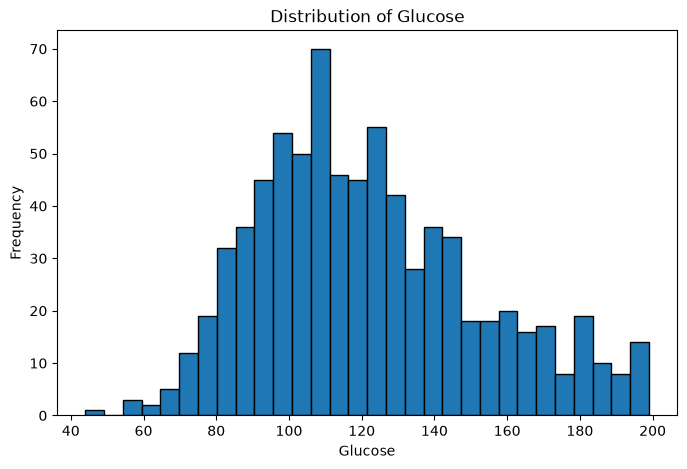

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Glucose"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

In [22]:
df_clean["Glucose"].describe()

count    763.000000
mean     121.686763
std       30.535641
min       44.000000
25%       99.000000
50%      117.000000
75%      141.000000
max      199.000000
Name: Glucose, dtype: float64

In [23]:
print("Skewness:", round(df_clean["Glucose"].skew(), 3))

Skewness: 0.531


### Phân tích - Phân bổ Glucose

Sau khi thay các giá trị không hợp lệ bằng giá trị còn thiếu, còn lại 763 phép đo đường huyết hợp lệ.

Mức đường huyết trung bình xấp xỉ 121,69, trong khi giá trị trung vị là 117. Phân bố có độ lệch 0,531, cho thấy một độ lệch dương (hướng phải) vừa phải.

Hầu hết các quan sát tập trung quanh phạm vi trung bình, trong khi một số bệnh nhân có giá trị glucose tương đối cao.

Glucose cũng có mối quan hệ tuyến tính mạnh nhất với kết quả bệnh tiểu đường trong số sáu đặc trưng được chọn, làm cho nó trở thành một đặc trưng quan trọng cho hệ thống dự đoán.

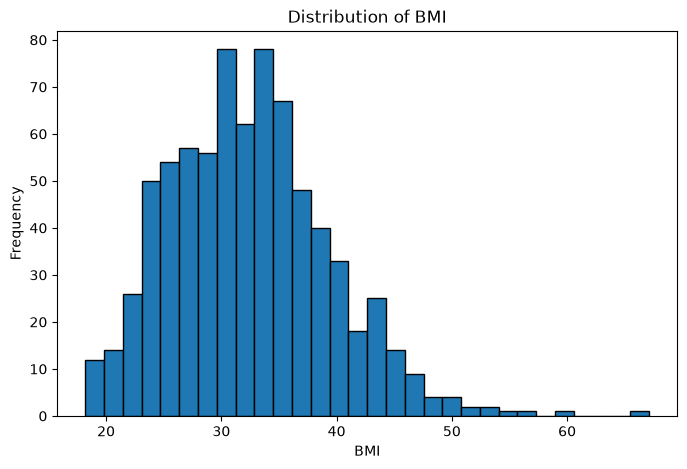

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["BMI"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

In [25]:
df_clean["BMI"].describe()

count    757.000000
mean      32.457464
std        6.924988
min       18.200000
25%       27.500000
50%       32.300000
75%       36.600000
max       67.100000
Name: BMI, dtype: float64

In [26]:
print("Skewness:", round(df_clean["BMI"].skew(), 3))

Skewness: 0.594


### Phân tích - Phân bổ BMI

Sau khi thay các giá trị không hợp lệ bằng giá trị thiếu, vẫn còn 757 phép đo BMI hợp lệ.

Giá trị trung bình BMI xấp xỉ 32,46, trong khi giá trị trung vị là 32,30. Phân phối có độ lệch 0,594, cho thấy có độ lệch dương (bên phải) vừa phải.

Hầu hết các giá trị BMI tập trung quanh phạm vi giữa, trong khi một số quan sát có giá trị BMI tương đối cao.

BMI cũng có mối tương quan tuyến tính mạnh thứ hai với kết quả bệnh tiểu đường trong số sáu đặc trưng được chọn, sau Glucose. Do đó, BMI có thể cung cấp thông tin hữu ích cho việc dự đoán bệnh tiểu đường.

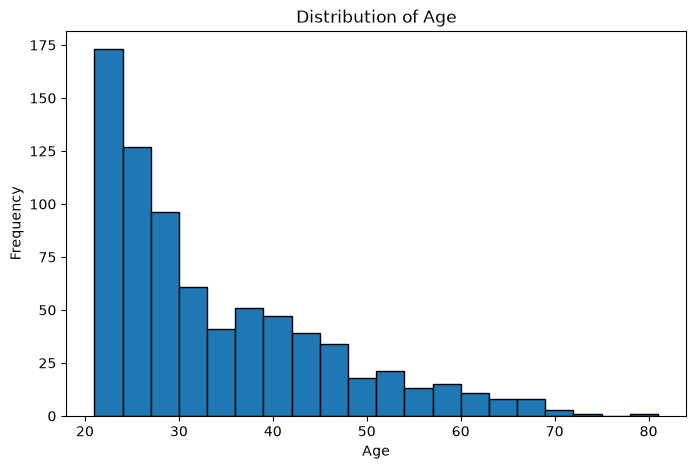

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["Age"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [28]:
df_clean["Age"].describe()

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

In [29]:
print(
    "Skewness:",
    round(df_clean["Age"].skew(), 3)
)

Skewness: 1.13


### Phân tích - Phân bổ Age

Bộ dữ liệu chứa 768 quan sát tuổi hợp lệ, dao động từ 21 đến 81 tuổi.

Tuổi trung bình xấp xỉ 33,24 tuổi, trong khi tuổi trung vị là 29 tuổi. Vì trung bình lớn hơn trung vị và độ nghiêng là 1,13, phân bố độ tuổi bị lệch dương (lệch phải).

Điều này cho thấy rằng bộ dữ liệu chứa một tỷ lệ cao hơn các bệnh nhân trẻ tuổi, trong khi có ít quan sát hơn thuộc các nhóm tuổi lớn hơn.

Age cũng cho thấy mối tương quan tích cực với kết quả bệnh tiểu đường, gợi ý rằng nó có thể cung cấp thông tin hữu ích cho việc dự đoán bệnh tiểu đường.

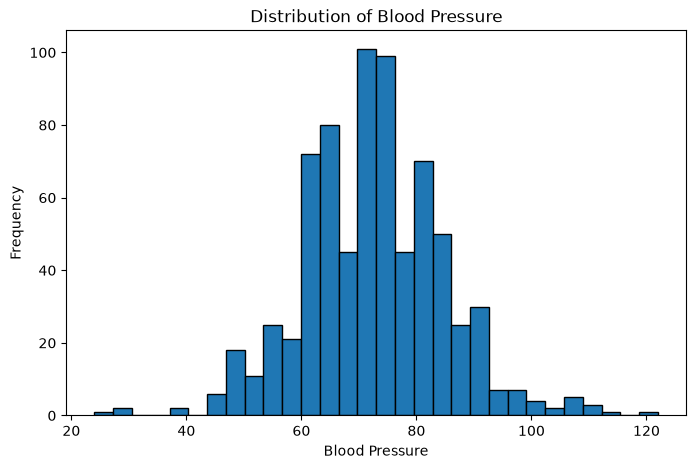

In [30]:
plt.figure(figsize=(8, 5))

plt.hist(
    df_clean["BloodPressure"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Blood Pressure")
plt.xlabel("Blood Pressure")
plt.ylabel("Frequency")

plt.show()

In [31]:
df_clean["BloodPressure"].describe()

count    733.000000
mean      72.405184
std       12.382158
min       24.000000
25%       64.000000
50%       72.000000
75%       80.000000
max      122.000000
Name: BloodPressure, dtype: float64

In [32]:
print(
    "Skewness:",
    round(df_clean["BloodPressure"].skew(), 3)
)

Skewness: 0.134


### Phân tích - Phân bố huyết áp

Sau khi thay thế các giá trị không hợp lệ bằng giá trị thiếu, vẫn còn 733 phép đo huyết áp hợp lệ.

Huyết áp trung bình xấp xỉ 72,41, trong khi trung vị là 72. Độ lệch (skewness) là 0,134, gần bằng với 0.

Điều này cho thấy phân bố huyết áp xấp xỉ đối xứng, chỉ có một độ lệch dương nhẹ.

Hầu hết các quan sát tập trung quanh phạm vi trung bình, trong khi tương đối ít bệnh nhân có giá trị huyết áp rất thấp hoặc rất cao.

BloodPressure có mối tương quan tuyến tính yếu hơn với kết quả bệnh tiểu đường so với Glucose, BMI, Age và Pregnancies, nhưng nó vẫn được giữ lại như một trong sáu đặc tính y tế được chọn.

## 7. Chia dữ liệu thành tập huấn luyện/và kiểm tra

Bộ dữ liệu được chia một lần bằng cách sử dụng phương pháp phân tầng để bộ dữ liệu huấn luyện và test duy trì tỷ lệ lớp tương tự. Tất cả việc lựa chọn và tinh chỉnh mô hình sau khi chia này chỉ sử dụng các quan sát trong bộ huấn luyện; bộ dữ liệu test giữ lại được dành cho việc đánh giá.

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X = df_clean[selected_features].copy()
y = df_clean[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 6)
y shape: (768,)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [36]:
print("Training class distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .round(3)
)

print("\nTesting class distribution:")
print(
    y_test.value_counts(normalize=True)
    .sort_index()
    .round(3)
)

Training class distribution:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


## 8. Tiền xử lý

Các đặc điểm được chọn là dạng số. Một số giá trị không hợp lệ bằng không trong các phép đo y tế trước đó đã được chuyển sang giá trị thiếu (`NaN`).

Để chuẩn bị dữ liệu cho các mô hình học máy:

1. Giá trị thiếu được thay thế bằng giá trị trung vị của từng đặc trưng.
2. Các đặc trưng số được chuẩn hóa bằng StandardScaler.

Các bước tiền xử lý này được đặt bên trong một Scikit-learn Pipeline để phép biến đổi chỉ được học từ dữ liệu huấn luyện, giúp ngăn ngừa rò rỉ dữ liệu và đảm bảo rằng cùng một tiền xử lý được sử dụng cho dữ liệu đầu vào mới trong quá trình triển khai.

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [38]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print(preprocessor)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


## 9. Mô hình cơ bản

Trước khi đào tạo các mô hình học máy chính, một mô hình cơ bản đơn giản được tạo ra.

Đường cơ sở dự đoán lớp xuất hiện thường xuyên nhất trong dữ liệu huấn luyện. Nó cung cấp một hiệu suất tham chiếu mà các mô hình học máy đã được huấn luyện nên vượt qua.

Cùng một quy trình tiền xử lý được sử dụng để các giá trị thiếu và biến đổi đặc trưng được xử lý một cách nhất quán.

In [39]:
from sklearn.dummy import DummyClassifier

In [40]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each colum

In [41]:
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [42]:
baseline_pred = baseline_model.predict(X_test)

print("Number of predictions:", len(baseline_pred))
print("First 20 predictions:")
print(baseline_pred[:20])

Number of predictions: 154
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [44]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("Baseline Accuracy :", round(baseline_accuracy, 4))
print("Baseline Precision:", round(baseline_precision, 4))
print("Baseline Recall   :", round(baseline_recall, 4))
print("Baseline F1-score :", round(baseline_f1, 4))

Baseline Accuracy : 0.6494
Baseline Precision: 0.0
Baseline Recall   : 0.0
Baseline F1-score : 0.0


In [45]:
baseline_cm = confusion_matrix(y_test, baseline_pred)

print("Baseline Confusion Matrix:")
print(baseline_cm)

Baseline Confusion Matrix:
[[100   0]
 [ 54   0]]


### Phân tích cơ bản

Mô hình cơ sở đạt độ chính xác 64,94%. Tuy nhiên, ma trận nhầm lẫn cho thấy mô hình dự đoán mọi quan sát trong tập kiểm tra là lớp không bị tiểu đường.

Ma trận nhầm lẫn là:

- Âm tính thật (TN): 100
- Dương tính giả (FP): 0
- Âm tính giả (FN): 54
- Dương tính thật (TP): 0

Mặc dù độ chính xác có vẻ tương đối cao, mô hình đã không xác định đúng bất kỳ bệnh nhân tiểu đường nào. Do đó, Precision, Recall, và F1-score cho lớp bệnh tiểu đường đều là 0.

Điều này cho thấy lý do tại sao Accuracy một mình không đủ để đánh giá vấn đề phân loại này. Mức cơ bản cung cấp một tham chiếu tối thiểu mà các mô hình học máy nên cải thiện.

## 10. Logistic Regression

Logistic Regression được sử dụng như mô hình phân loại học máy đầu tiên.

Nó ước tính xác suất một bệnh nhân thuộc lớp tiểu đường (`Outcome = 1`) dựa trên sáu đặc trưng đầu vào đã chọn.

Các bước tiền xử lý tương tự được áp dụng trước khi phân loại:
- Các giá trị bị thiếu được ước lượng bằng trung vị.
- Các đặc trưng số được chuẩn hóa bằng StandardScaler.

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each colum

In [48]:
logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [49]:
logistic_pred = logistic_model.predict(X_test)

print("Number of predictions:", len(logistic_pred))
print("First 20 predictions:")
print(logistic_pred[:20])

Number of predictions: 154
First 20 predictions:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]


In [50]:
logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred, zero_division=0)
logistic_recall = recall_score(y_test, logistic_pred, zero_division=0)
logistic_f1 = f1_score(y_test, logistic_pred, zero_division=0)

print("Logistic Regression Accuracy :", round(logistic_accuracy, 4))
print("Logistic Regression Precision:", round(logistic_precision, 4))
print("Logistic Regression Recall   :", round(logistic_recall, 4))
print("Logistic Regression F1-score :", round(logistic_f1, 4))

Logistic Regression Accuracy : 0.7013
Logistic Regression Precision: 0.5909
Logistic Regression Recall   : 0.4815
Logistic Regression F1-score : 0.5306


In [51]:
logistic_cm = confusion_matrix(y_test, logistic_pred)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

Logistic Regression Confusion Matrix:
[[82 18]
 [28 26]]


### Logistic Regression Phân tích

Mẫu Logistic Regression đạt độ chính xác 70,13%, cao hơn độ chính xác chuẩn là 64,94%.

Mô hình đạt độ chính xác 59,09%, độ hồi tưởng 48,15%, và F1-score 53,06%.

Ma trận nhầm lẫn hiển thị:

- Dương tính thật (TN): 82
- Dương tính giả (FP): 18
- Âm tính giả (FN): 28
- Âm tính thật (TP): 26

So với mô hình cơ bản, Logistic Regression có khả năng xác định bệnh nhân tiểu đường thay vì chỉ dự đoán lớp chiếm đa số.

Tuy nhiên, độ nhạy vẫn tương đối thấp vì 28 bệnh nhân tiểu đường đã bị phân loại sai thành không tiểu đường.

Do đó, Logistic Regression cải thiện đáng kể so với mức cơ sở, nhưng vẫn còn chỗ để cải thiện, đặc biệt là trong việc phát hiện các ca bệnh tiểu đường dương tính.

## 11. K-Nearest Neighbors

K-Nearest Neighbors (KNN) là mô hình phân loại học máy thứ hai.

KNN dự đoán lớp của một bệnh nhân mới dựa trên các lớp của những bệnh nhân tương tự nhất trong dữ liệu huấn luyện.

Bởi vì KNN dựa trên khoảng cách giữa các quan sát, việc chuẩn hóa các đặc trưng là quan trọng. Do đó, cùng một quy trình tiền xử lý với việc suy đoán trung vị và StandardScaler được sử dụng trước bộ phân loại KNN.

In [52]:
from sklearn.neighbors import KNeighborsClassifier

In [53]:
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each colum

In [54]:
knn_model.fit(X_train, y_train)

print("KNN trained successfully.")

KNN trained successfully.


In [55]:
knn_pred = knn_model.predict(X_test)

print("Number of predictions:", len(knn_pred))
print("First 20 predictions:")
print(knn_pred[:20])

Number of predictions: 154
First 20 predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 1 0 1 0]


In [56]:
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, zero_division=0)
knn_recall = recall_score(y_test, knn_pred, zero_division=0)
knn_f1 = f1_score(y_test, knn_pred, zero_division=0)

print("KNN Accuracy :", round(knn_accuracy, 4))
print("KNN Precision:", round(knn_precision, 4))
print("KNN Recall   :", round(knn_recall, 4))
print("KNN F1-score :", round(knn_f1, 4))

KNN Accuracy : 0.7338
KNN Precision: 0.6327
KNN Recall   : 0.5741
KNN F1-score : 0.6019


In [57]:
knn_cm = confusion_matrix(y_test, knn_pred)

print("KNN Confusion Matrix:")
print(knn_cm)

KNN Confusion Matrix:
[[82 18]
 [23 31]]


### KNN Phân tích

Mô hình KNN đạt được độ chính xác 73,38%, độ chính xác (precision) 63,27%, độ hồi tưởng (recall) 57,41%, và F1-score 60,19%.

Ma trận nhầm lẫn hiển thị:

- Âm tính thật (TN): 82
- Dương tính giả (FP): 18
- Âm tính giả (FN): 23
- Dương tính thật (TP): 31

So với Logistic Regression, KNN đạt hiệu suất tốt hơn trên cả bốn chỉ số đánh giá.

KNN cũng đã xác định chính xác nhiều bệnh nhân tiểu đường hơn, tăng số lượng các kết quả dương tính thật từ 26 lên 31 và giảm các kết quả âm tính giả từ 28 xuống 23.

Tuy nhiên, vẫn còn 23 bệnh nhân tiểu đường bị phân loại sai thành không tiểu đường, vì vậy vẫn còn chỗ để cải thiện.

## 12. Decision Tree

Decision Tree là mô hình phân loại học máy thứ ba.

Nó phân loại bệnh nhân bằng cách chia không gian đặc trưng một cách đệ quy dựa trên các quy tắc quyết định học được từ dữ liệu huấn luyện.

Không giống như KNN và Logistic Regression, Decision Tree không phụ thuộc nhiều vào việc chuẩn hóa đặc trưng. Tuy nhiên, cùng một quy trình tiền xử lý vẫn được sử dụng để giữ cho quy trình làm việc nhất quán giữa các mô hình.

In [58]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each colum

In [60]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [61]:
decision_tree_pred = decision_tree_model.predict(X_test)

print("Number of predictions:", len(decision_tree_pred))
print("First 20 predictions:")
print(decision_tree_pred[:20])

Number of predictions: 154
First 20 predictions:
[0 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]


In [62]:
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)
decision_tree_precision = precision_score(y_test, decision_tree_pred, zero_division=0)
decision_tree_recall = recall_score(y_test, decision_tree_pred, zero_division=0)
decision_tree_f1 = f1_score(y_test, decision_tree_pred, zero_division=0)

print("Decision Tree Accuracy :", round(decision_tree_accuracy, 4))
print("Decision Tree Precision:", round(decision_tree_precision, 4))
print("Decision Tree Recall   :", round(decision_tree_recall, 4))
print("Decision Tree F1-score :", round(decision_tree_f1, 4))

Decision Tree Accuracy : 0.6818
Decision Tree Precision: 0.551
Decision Tree Recall   : 0.5
Decision Tree F1-score : 0.5243


In [63]:
decision_tree_cm = confusion_matrix(y_test, decision_tree_pred)

print("Decision Tree Confusion Matrix:")
print(decision_tree_cm)

Decision Tree Confusion Matrix:
[[78 22]
 [27 27]]


### Decision Tree Phân tích

Mô hình Decision Tree đạt độ chính xác 68,18%, độ chính xác (precision) 55,10%, độ nhạy (recall) 50,00%, và F1-score 52,43%.

Ma trận nhầm lẫn hiển thị:

- Âm tính thật (TN): 78
- Dương tính giả (FP): 22
- Âm tính giả (FN): 27
- Dương tính thật (TP): 27

So với KNN, mô hình Decision Tree đạt hiệu suất thấp hơn trên tất cả bốn chỉ số đánh giá.

Mô hình đã xác định đúng 27 bệnh nhân tiểu đường nhưng không phát hiện được 27 bệnh nhân tiểu đường khác.

Điều này cho thấy cấu hình Decision Tree hiện tại không hoạt động tốt bằng KNN trên tập dữ liệu này.

Tuy nhiên, hiệu suất của Decision Tree có thể thay đổi khi các siêu tham số như độ sâu tối đa của cây hoặc số lượng mẫu tối thiểu cho mỗi lần tách được điều chỉnh trong các thí nghiệm có kiểm soát sau này.

## 13. Random Forest

Random Forest là mô hình phân loại học máy thứ tư.

Nó kết hợp nhiều Decision Tree và tổng hợp các dự đoán của chúng để tạo ra kết quả phân loại cuối cùng.

So với một Decision Tree đơn lẻ, Random Forest có thể giảm hiện tượng quá khớp và thường cung cấp các dự đoán ổn định hơn.

Cùng một quy trình tiền xử lý được sử dụng để các giá trị bị thiếu được xử lý một cách nhất quán trên tất cả các mô hình.

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each colum

In [66]:
random_forest_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [67]:
random_forest_pred = random_forest_model.predict(X_test)

print("Number of predictions:", len(random_forest_pred))
print("First 20 predictions:")
print(random_forest_pred[:20])

Number of predictions: 154
First 20 predictions:
[1 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0]


In [68]:
random_forest_accuracy = accuracy_score(y_test, random_forest_pred)
random_forest_precision = precision_score(
    y_test,
    random_forest_pred,
    zero_division=0
)
random_forest_recall = recall_score(
    y_test,
    random_forest_pred,
    zero_division=0
)
random_forest_f1 = f1_score(
    y_test,
    random_forest_pred,
    zero_division=0
)

print("Random Forest Accuracy :", round(random_forest_accuracy, 4))
print("Random Forest Precision:", round(random_forest_precision, 4))
print("Random Forest Recall   :", round(random_forest_recall, 4))
print("Random Forest F1-score :", round(random_forest_f1, 4))

Random Forest Accuracy : 0.7597
Random Forest Precision: 0.6735
Random Forest Recall   : 0.6111
Random Forest F1-score : 0.6408


In [69]:
random_forest_cm = confusion_matrix(
    y_test,
    random_forest_pred
)

print("Random Forest Confusion Matrix:")
print(random_forest_cm)

Random Forest Confusion Matrix:
[[84 16]
 [21 33]]


### Random Forest Phân tích

Mô hình Random Forest đạt độ chính xác 75,97%, độ chính xác định lượng 67,35%, độ nhạy 61,11% và F1-score là 64,08%.

Ma trận nhầm lẫn hiển thị:

- Âm tính thật (TN): 84
- Dương tính giả (FP): 16
- Âm tính giả (FN): 21
- Dương tính thật (TP): 33

So với các mẫu trước, Random Forest đã đạt được hiệu suất tổng thể tốt nhất cho đến nay.

Nó đã xác định chính xác 33 bệnh nhân tiểu đường và giảm số lượng kết quả âm tính giả xuống còn 21.

Độ nhắc lại cao hơn và F1-score cho thấy rằng Random Forest tốt hơn trong việc phát hiện các ca bệnh tiểu đường trong khi vẫn duy trì hiệu suất phân loại tổng thể tương đối tốt.

Do đó, Random Forest hiện là mô hình mạnh nhất trong số các mô hình đã được đánh giá cho đến nay.

## 14. Support Vector Machine

Support Vector Machine (SVM) là bộ phân loại học máy thứ năm. Một kernel RBF được sử dụng để học một ranh giới quyết định phi tuyến, với việc nhập trung vị và chuẩn hóa Pipeline giống như được sử dụng cho các mô hình khác.

In [70]:
from sklearn.svm import SVC

In [71]:
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf"
    ))
])

svm_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each colum

In [72]:
svm_model.fit(X_train, y_train)

print("SVM trained successfully.")

SVM trained successfully.


In [73]:
svm_pred = svm_model.predict(X_test)

print("Number of predictions:", len(svm_pred))
print("First 20 predictions:")
print(svm_pred[:20])

Number of predictions: 154
First 20 predictions:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]


In [74]:
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, zero_division=0)
svm_recall = recall_score(y_test, svm_pred, zero_division=0)
svm_f1 = f1_score(y_test, svm_pred, zero_division=0)

print("SVM Accuracy :", round(svm_accuracy, 4))
print("SVM Precision:", round(svm_precision, 4))
print("SVM Recall   :", round(svm_recall, 4))
print("SVM F1-score :", round(svm_f1, 4))

SVM Accuracy : 0.7338
SVM Precision: 0.6512
SVM Recall   : 0.5185
SVM F1-score : 0.5773


In [75]:
svm_cm = confusion_matrix(y_test, svm_pred)

print("SVM Confusion Matrix:")
print(svm_cm)

SVM Confusion Matrix:
[[85 15]
 [26 28]]


### SVM Phân tích

Mô hình SVM đạt độ chính xác 73,38%, độ chính xác định lượng 65,12%, độ nhạy 51,85% và F1-score 57,73%.

Ma trận nhầm lẫn hiển thị:

- Âm tính thật (TN): 85
- Dương tính giả (FP): 15
- Âm tính giả (FN): 26
- Dương tính thật (TP): 28

Mẫu SVM đạt được cùng độ chính xác như KNN nhưng có độ chính xác cao hơn.

Tuy nhiên, độ nhạy và F1-score của nó thấp hơn so với KNN, nghĩa là SVM bỏ sót nhiều bệnh nhân tiểu đường hơn.

So với Random Forest, SVM cũng có độ nhạy thấp hơn và F1-score.

Do đó, SVM hoạt động khá tốt, nhưng Random Forest vẫn là mô hình mạnh nhất trong số năm mô hình được đánh giá cho đến nay.

## 15. So sánh Mô hình

Hiệu suất của mô hình cơ sở và năm mô hình học máy được tóm tắt bằng cách sử dụng Accuracy, Precision, Recall và F1-score.

In [76]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        knn_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        svm_accuracy
    ],
    "Precision": [
        baseline_precision,
        logistic_precision,
        knn_precision,
        decision_tree_precision,
        random_forest_precision,
        svm_precision
    ],
    "Recall": [
        baseline_recall,
        logistic_recall,
        knn_recall,
        decision_tree_recall,
        random_forest_recall,
        svm_recall
    ],
    "F1-score": [
        baseline_f1,
        logistic_f1,
        knn_f1,
        decision_tree_f1,
        random_forest_f1,
        svm_f1
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline,0.6494,0.0000,0.0000,0.0000
1,Logistic Regression,0.7013,0.5909,0.4815,0.5306
2,KNN,0.7338,0.6327,0.5741,0.6019
3,Decision Tree,0.6818,0.5510,0.5000,0.5243
4,Random Forest,0.7597,0.6735,0.6111,0.6408
5,SVM,0.7338,0.6512,0.5185,0.5773


### Phân tích so sánh mô hình

Kết quả cho thấy tất cả các mô hình học máy đều vượt trội hơn mô hình cơ bản về khả năng phát hiện bệnh nhân tiểu đường.

Trong số năm mô hình được huấn luyện, Random Forest đạt hiệu suất tổng thể tốt nhất:

- Accuracy: 75,97%
- Precision: 67,35%
- Recall: 61,11%
- F1-score: 64,08%

KNN đạt được F1-score tốt thứ hai là 60,19%, trong khi SVM đạt được cùng độ chính xác như KNN nhưng có recall và F1-score thấp hơn.

Logistic Regression cải thiện so với mức cơ bản nhưng vẫn có độ truy hồi tương đối thấp.

Decision Tree độc lập tạo ra hiệu quả thấp hơn Random Forest, gợi ý rằng việc kết hợp nhiều cây cung cấp các dự đoán ổn định hơn so với việc sử dụng một cây duy nhất.

Dựa trên kết quả đánh giá hiện tại, Random Forest là mô hình mạnh nhất trong số năm mô hình được thử nghiệm.

Tuy nhiên, đây vẫn chưa phải là lựa chọn mô hình cuối cùng vì các thí nghiệm có kiểm soát và phân tích siêu tham số sẽ được thực hiện thêm.

### Trực quan hóa Hiệu suất Mô hình

Biểu đồ sau so sánh Accuracy, Precision, Recall và F1-score trên cơ sở chuẩn và năm mô hình học máy.

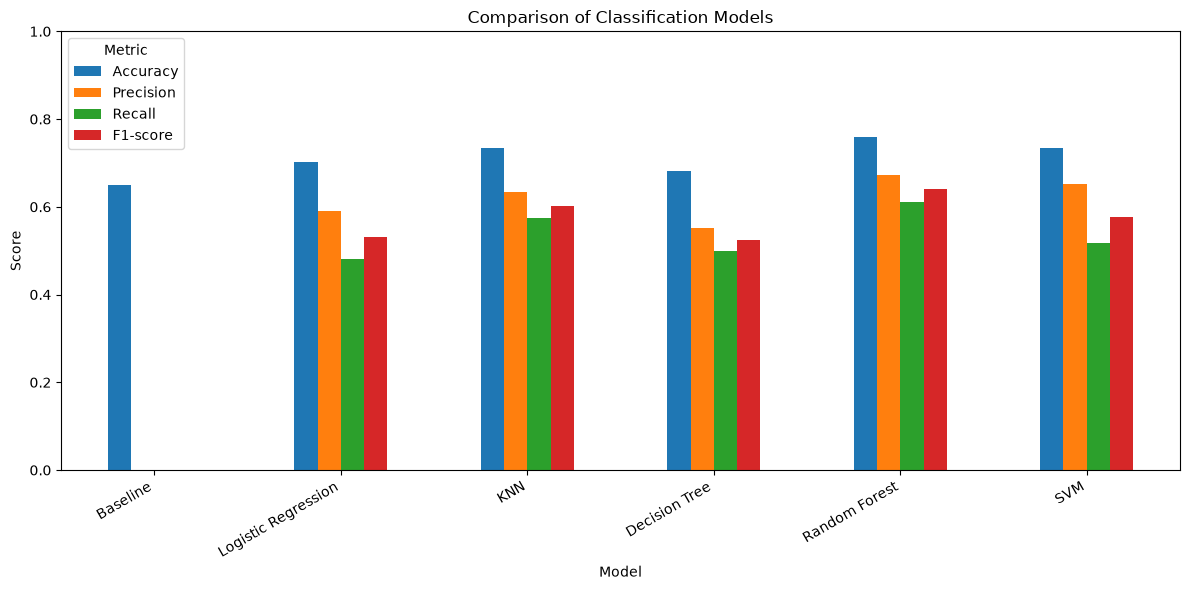

In [77]:
comparison_plot = model_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

### Phân tích Hiệu suất Mô hình

Bảng so sánh xác nhận những khác biệt được quan sát trong bảng đánh giá.

Mô hình cơ sở đạt độ chính xác tương đối cao vì nó dự đoán lớp chiếm đa số, nhưng Precision, Recall, và F1-score của nó đều bằng không. Điều này cho thấy chỉ số độ chính xác đơn thuần có thể gây hiểu lầm đối với bài toán phân loại này.

Trong số năm mô hình học máy, Random Forest đạt hiệu suất tổng thể mạnh nhất trên Accuracy, Precision, Recall, và F1-score.

KNN cung cấp sự cân bằng tốt thứ hai giữa Precision và Recall, trong khi SVM đạt được Precision tương đối cao nhưng Recall thấp hơn.

Decision Tree hoạt động kém hơn Random Forest, cho thấy rằng kết hợp nhiều cây tạo ra dự đoán ổn định và hiệu quả hơn so với dựa vào một cây duy nhất.

Tổng thể, Random Forest hiện cung cấp sự cân bằng tốt nhất về hiệu quả phân loại, đặc biệt là trong việc phát hiện bệnh nhân tiểu đường.

## 16. Thí nghiệm có kiểm soát

### Thí nghiệm 1 - So sánh mô hình

#### Mục tiêu

Mục tiêu của thí nghiệm này là so sánh các thuật toán phân loại khác nhau dưới cùng điều kiện thí nghiệm.

#### Điều kiện được kiểm soát

Các điều kiện sau đây được giữ nguyên:

- Bộ dữ liệu: Bộ dữ liệu tiểu đường
- Các đặc trưng được chọn: 6
- Tách tập huấn luyện/kiểm tra: 80/20
- Trạng thái ngẫu nhiên: 42
- Tách theo tầng
- Xử lý giá trị thiếu: Thay bằng trung vị
- Chuẩn hóa đặc trưng: StandardScaler
- Bộ dữ liệu đánh giá: Cùng một tập kiểm tra
- Các chỉ số đánh giá: Accuracy, Precision, Recall, và F1-score

#### Biến độc lập

Thuật toán học máy đã được thay đổi:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Support Vector Machine

#### Kết quả

Random Forest đạt hiệu suất tổng thể mạnh nhất:

- Accuracy: 75,97%
- Precision: 67,35%
- Recall: 61,11%
- F1-score: 64,08%

#### Kết luận

Dưới cùng một phương pháp biểu diễn dữ liệu, tiền xử lý và chia dữ liệu train/test, Random Forest thực hiện tốt hơn so với các thuật toán phân loại khác đã được thử.

Điều này gợi ý rằng lựa chọn thuật toán học có ảnh hưởng có thể đo lường được đối với hiệu suất dự đoán.

### Thí nghiệm 2 - Phân tích Siêu tham số Random Forest

#### Mục tiêu

Mục tiêu của thí nghiệm này là nghiên cứu cách mà siêu tham số `max_depth` ảnh hưởng đến hiệu suất của bộ phân loại Random Forest.

#### Điều kiện được kiểm soát

Các điều kiện sau đây được giữ nguyên:

- Bộ dữ liệu
- Sáu đặc trưng đầu vào được chọn
- Dữ liệu huấn luyện
- Xử lý giá trị thiếu
- Chuẩn hóa đặc trưng
- Thuật toán Random Forest
- Trạng thái ngẫu nhiên

#### Biến độc lập

Chỉ có tham số `max_depth` của Random Forest bị thay đổi.

Các giá trị sau sẽ được điều tra:

- `max_depth = 2`
- `max_depth = 4`
- `max_depth = 6`
- `max_depth = 8`
- `max_depth = None`

#### Phương pháp đánh giá

Thí nghiệm sẽ sử dụng kiểm tra chéo trên tập huấn luyện.

F1-score sẽ được sử dụng như là chỉ số so sánh chính vì cả kết quả dương tính giả và kết quả âm tính giả đều quan trọng trong bài toán phân loại này.

Bộ dữ liệu kiểm tra sẽ không được sử dụng để chọn siêu tham số.

In [78]:
from sklearn.model_selection import cross_val_score

In [79]:
max_depth_values = [2, 4, 6, 8, None]

print("max_depth values to test:")
print(max_depth_values)

max_depth values to test:
[2, 4, 6, 8, None]


In [80]:
experiment_2_results = []

print("Result container created.")

Result container created.


In [81]:
rf_depth_2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=2,
        random_state=42
    ))
])

In [82]:
rf_depth_2_scores = cross_val_score(
    rf_depth_2,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 scores for each fold:")
print(rf_depth_2_scores)

print(
    "Mean F1-score:",
    round(rf_depth_2_scores.mean(), 4)
)

F1 scores for each fold:
[0.61971831 0.50746269 0.48387097 0.50793651 0.63768116]
Mean F1-score: 0.5513


In [83]:
experiment_2_results.append({
    "max_depth": 2,
    "mean_f1": rf_depth_2_scores.mean()
})

experiment_2_results

[{'max_depth': 2, 'mean_f1': np.float64(0.5513339263050104)}]

In [84]:
rf_depth_4 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        random_state=42
    ))
])

In [85]:
rf_depth_4_scores = cross_val_score(
    rf_depth_4,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 scores for each fold:")
print(rf_depth_4_scores)

print(
    "Mean F1-score:",
    round(rf_depth_4_scores.mean(), 4)
)

F1 scores for each fold:
[0.65       0.64935065 0.58666667 0.52307692 0.7027027 ]
Mean F1-score: 0.6224


In [86]:
experiment_2_results.append({
    "max_depth": 4,
    "mean_f1": rf_depth_4_scores.mean()
})

experiment_2_results

[{'max_depth': 2, 'mean_f1': np.float64(0.5513339263050104)},
 {'max_depth': 4, 'mean_f1': np.float64(0.6223593883593883)}]

In [87]:
rf_depth_6 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

In [88]:
rf_depth_6_scores = cross_val_score(
    rf_depth_6,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 scores for each fold:")
print(rf_depth_6_scores)

print(
    "Mean F1-score:",
    round(rf_depth_6_scores.mean(), 4)
)

F1 scores for each fold:
[0.61904762 0.65822785 0.64102564 0.62857143 0.68421053]
Mean F1-score: 0.6462


In [89]:
experiment_2_results.append({
    "max_depth": 6,
    "mean_f1": rf_depth_6_scores.mean()
})

experiment_2_results

[{'max_depth': 2, 'mean_f1': np.float64(0.5513339263050104)},
 {'max_depth': 4, 'mean_f1': np.float64(0.6223593883593883)},
 {'max_depth': 6, 'mean_f1': np.float64(0.6462166126123488)}]

In [90]:
rf_depth_8 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        random_state=42
    ))
])

In [91]:
rf_depth_8_scores = cross_val_score(
    rf_depth_8,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 scores for each fold:")
print(rf_depth_8_scores)

print(
    "Mean F1-score:",
    round(rf_depth_8_scores.mean(), 4)
)

F1 scores for each fold:
[0.59770115 0.65789474 0.625      0.62857143 0.69230769]
Mean F1-score: 0.6403


In [92]:
experiment_2_results.append({
    "max_depth": 8,
    "mean_f1": rf_depth_8_scores.mean()
})

experiment_2_results

[{'max_depth': 2, 'mean_f1': np.float64(0.5513339263050104)},
 {'max_depth': 4, 'mean_f1': np.float64(0.6223593883593883)},
 {'max_depth': 6, 'mean_f1': np.float64(0.6462166126123488)},
 {'max_depth': 8, 'mean_f1': np.float64(0.6402950014293027)}]

In [93]:
rf_depth_none = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42
    ))
])

In [94]:
rf_depth_none_scores = cross_val_score(
    rf_depth_none,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1 scores for each fold:")
print(rf_depth_none_scores)

print(
    "Mean F1-score:",
    round(rf_depth_none_scores.mean(), 4)
)

F1 scores for each fold:
[0.61363636 0.65822785 0.56410256 0.60273973 0.675     ]
Mean F1-score: 0.6227


In [95]:
experiment_2_results.append({
    "max_depth": None,
    "mean_f1": rf_depth_none_scores.mean()
})

experiment_2_results

[{'max_depth': 2, 'mean_f1': np.float64(0.5513339263050104)},
 {'max_depth': 4, 'mean_f1': np.float64(0.6223593883593883)},
 {'max_depth': 6, 'mean_f1': np.float64(0.6462166126123488)},
 {'max_depth': 8, 'mean_f1': np.float64(0.6402950014293027)},
 {'max_depth': None, 'mean_f1': np.float64(0.6227413003735182)}]

In [96]:
experiment_2_df = pd.DataFrame(experiment_2_results)

experiment_2_df["max_depth"] = (
    experiment_2_df["max_depth"]
    .astype(object)
    .where(experiment_2_df["max_depth"].notna(), "None")
)

experiment_2_df["mean_f1"] = experiment_2_df["mean_f1"].round(4)

experiment_2_df

,max_depth,mean_f1
0,2.0,0.5513
1,4.0,0.6224
2,6.0,0.6462
3,8.0,0.6403
4,None,0.6227


In [97]:
best_index = experiment_2_df["mean_f1"].idxmax()

best_depth = experiment_2_df.loc[best_index, "max_depth"]
best_f1 = experiment_2_df.loc[best_index, "mean_f1"]

print("Best max_depth:", best_depth)
print("Best mean F1-score:", best_f1)

Best max_depth: 6.0
Best mean F1-score: 0.6462


#### Phân tích Thí nghiệm 2

Siêu tham số Random Forest `max_depth` đã được đánh giá bằng cách sử dụng kiểm tra chéo 5 lần trên tập huấn luyện.

Các F1-score trung bình là:

- `max_depth = 2`: 0.5513
- `max_depth = 4`: 0.6224
- `max_depth = 6`: 0.6462
- `max_depth = 8`: 0.6403
- `max_depth = None`: 0.6227

Kết quả tốt nhất đạt được với `max_depth = 6`, đạt trung bình F1-score là 0.6462.

Khi độ sâu tối đa quá nhỏ, chẳng hạn như `max_depth = 2`, mô hình tạo ra F1-score thấp hơn đáng kể, cho thấy các cây quá đơn giản để nắm bắt các mối quan hệ trong dữ liệu.

Tăng độ sâu đã cải thiện hiệu suất lên đến `max_depth = 6`. Tuy nhiên, việc tăng độ sâu lên 8 hoặc gỡ bỏ giới hạn độ sâu không cải thiện kết quả kiểm tra chéo.

Do đó, `max_depth = 6` cung cấp sự cân bằng tốt nhất trong số các giá trị đã được thử nghiệm và sẽ được sử dụng làm siêu tham số được chọn cho mô hình Random Forest đã được tinh chỉnh.

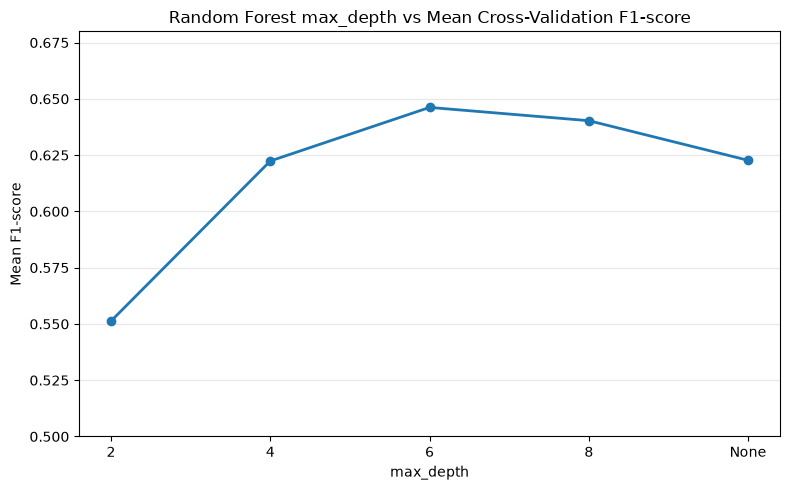

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\diabetes\experiment_2_max_depth.png


In [98]:
FIGURE_DIR = PROJECT_ROOT / "figures" / "diabetes"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

depth_labels = [str(value) for value in max_depth_values]

plt.figure(figsize=(8, 5))
plt.plot(
    depth_labels,
    experiment_2_df["mean_f1"],
    marker="o",
    linewidth=2
)
plt.title("Random Forest max_depth vs Mean Cross-Validation F1-score")
plt.xlabel("max_depth")
plt.ylabel("Mean F1-score")
plt.ylim(0.50, 0.68)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

experiment_2_figure = FIGURE_DIR / "experiment_2_max_depth.png"
plt.savefig(experiment_2_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", experiment_2_figure)

In [99]:
tuned_random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

tuned_random_forest.fit(X_train, y_train)
tuned_random_forest_pred = tuned_random_forest.predict(X_test)

tuned_rf_accuracy = accuracy_score(y_test, tuned_random_forest_pred)
tuned_rf_precision = precision_score(y_test, tuned_random_forest_pred, zero_division=0)
tuned_rf_recall = recall_score(y_test, tuned_random_forest_pred, zero_division=0)
tuned_rf_f1 = f1_score(y_test, tuned_random_forest_pred, zero_division=0)
tuned_rf_cm = confusion_matrix(y_test, tuned_random_forest_pred)

tuned_rf_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [tuned_rf_accuracy, tuned_rf_precision, tuned_rf_recall, tuned_rf_f1]
})

print(tuned_rf_metrics.round(4).to_string(index=False))
print("\nTuned Random Forest Confusion Matrix:")
print(tuned_rf_cm)

   Metric  Score
 Accuracy 0.7468
Precision 0.6667
   Recall 0.5556
 F1-score 0.6061

Tuned Random Forest Confusion Matrix:
[[85 15]
 [24 30]]


#### Phân tích thử nghiệm Random Forest đã tinh chỉnh

Random Forest đã được tinh chỉnh đạt được Accuracy 0,7468, Precision 0,6667, Recall 0,5556 và F1-score 0,6061 trên bộ dữ liệu kiểm tra giữ lại. Random Forest mặc định trước đó đã đạt được Accuracy 0,7597, Precision 0,6735, Recall 0,6111 và F1-score 0,6408. Do đó, việc giới hạn `max_depth` ở mức 6 **không** cải thiện kết quả kiểm tra cụ thể này; tất cả bốn chỉ số kiểm tra báo cáo đều giảm nhẹ.

Điều này không mâu thuẫn với thí nghiệm kiểm tra chéo. Giá trị trung bình kiểm tra chéo F1-score là 0,6462 ước lượng hiệu suất trên năm tập huấn luyện chia gập và được sử dụng để chọn `max_depth`. Kết quả kiểm tra F1-score là 0,6061 là ước lượng riêng từ một tập giữ lại chưa từng thấy trước đó. Một cấu hình hoạt động tốt nhất trung bình trên các tập huấn luyện không đảm bảo sẽ vượt trội hơn cấu hình khác trên mọi mẫu kiểm tra hữu hạn. Kết quả tập giữ lại được báo cáo để đánh giá và không được sử dụng để điều chỉnh siêu tham số đã chọn.

### Thí nghiệm 3 - Biểu diễn đặc trưng

#### Mục tiêu

Thí nghiệm này so sánh biểu diễn sáu đặc trưng được chọn với biểu diễn tám đặc trưng đầy đủ.

#### Điều kiện được kiểm soát

- Cùng 614 quan sát huấn luyện và giá trị mục tiêu
- Cùng bộ phân loại Random Forest với `n_estimators=100`, `max_depth=6`, và `random_state=42`
- Cùng phương pháp điền giá trị trung vị và chuẩn hóa Pipeline
- Cùng quy trình xác thực chéo 5 lần
- Cùng chỉ số đánh giá F1
- Không xóa hàng và không sử dụng bộ dữ liệu kiểm tra

#### Biến độc lập

Chỉ có đại diện đặc trưng thay đổi: sáu đặc trưng được chọn so với tất cả tám đặc trưng đầu vào ban đầu. Đối với đại diện tám đặc trưng, các giá trị không hợp lệ bằng 0 trong Glucose, BloodPressure, SkinThickness, Insulin và BMI vẫn được mã hóa là `NaN` trong `df_clean` và được thay thế giá trị bên trong mỗi phần nếp gấp huấn luyện.

In [100]:
all_features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X_train_6 = df_clean.loc[X_train.index, selected_features]
X_train_8 = df_clean.loc[X_train.index, all_features]

experiment_3_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

experiment_3_scores_6 = cross_val_score(
    experiment_3_model, X_train_6, y_train, cv=5, scoring="f1"
)
experiment_3_scores_8 = cross_val_score(
    experiment_3_model, X_train_8, y_train, cv=5, scoring="f1"
)

experiment_3_df = pd.DataFrame({
    "Representation": ["Selected 6 features", "All 8 features"],
    "Number of Features": [6, 8],
    "Mean F1": [experiment_3_scores_6.mean(), experiment_3_scores_8.mean()],
    "Std F1": [experiment_3_scores_6.std(), experiment_3_scores_8.std()]
})

print("Selected 6-feature fold F1 scores:", np.round(experiment_3_scores_6, 4))
print("All 8-feature fold F1 scores:     ", np.round(experiment_3_scores_8, 4))
print("\nExperiment 3 summary:")
print(experiment_3_df.round(4).to_string(index=False))

Selected 6-feature fold F1 scores: [0.619  0.6582 0.641  0.6286 0.6842]
All 8-feature fold F1 scores:      [0.642  0.6579 0.5789 0.5672 0.6753]

Experiment 3 summary:
     Representation  Number of Features  Mean F1  Std F1
Selected 6 features                   6   0.6462  0.0231
     All 8 features                   8   0.6243  0.0433


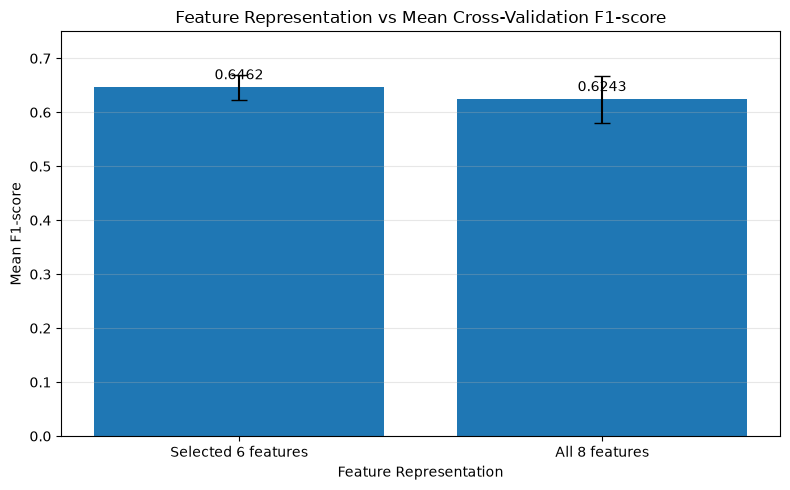

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\diabetes\experiment_3_feature_representation.png


In [101]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    experiment_3_df["Representation"],
    experiment_3_df["Mean F1"],
    yerr=experiment_3_df["Std F1"],
    capsize=6
)
plt.title("Feature Representation vs Mean Cross-Validation F1-score")
plt.xlabel("Feature Representation")
plt.ylabel("Mean F1-score")
plt.ylim(0, 0.75)
plt.grid(axis="y", alpha=0.3)
for bar, value in zip(bars, experiment_3_df["Mean F1"]):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.015, f"{value:.4f}", ha="center")
plt.tight_layout()

experiment_3_figure = FIGURE_DIR / "experiment_3_feature_representation.png"
plt.savefig(experiment_3_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", experiment_3_figure)

#### Kết quả

Biểu diễn sáu tính năng tạo ra các fold F1-score với các giá trị 0,6190, 0,6582, 0,6410, 0,6286 và 0,6842, với giá trị trung bình 0,6462 và độ lệch chuẩn 0,0231. Biểu diễn tám tính năng tạo ra các giá trị 0,6420, 0,6579, 0,5789, 0,5672 và 0,6753, với giá trị trung bình 0,6243 và độ lệch chuẩn 0,0433.

#### Phân tích

Dưới các điều kiện được kiểm soát, biểu diễn sáu tính năng đã chọn đạt trung bình F1-score cao hơn khoảng 0,0220 và cho thấy ít biến động giữa các lần chia mẫu hơn. Việc thêm SkinThickness và Insulin không cải thiện hiệu suất xác thực chéo được đo. Tỷ lệ đo bị thiếu cao của chúng có thể hạn chế đóng góp hữu ích, mặc dù chỉ thí nghiệm này không chứng minh được mối quan hệ nhân quả.

#### Kết luận

Biểu diễn sáu đặc trưng được chọn cho hệ thống cuối cùng vì nó thực hiện tốt hơn và nhất quán hơn trong so sánh chỉ sử dụng dữ liệu huấn luyện này. Kết luận này cụ thể đối với bộ dữ liệu, phương pháp tiền xử lý, cấu hình bộ phân loại và quy trình CV này; nó không khẳng định rằng sáu đặc trưng luôn vượt trội.

### So sánh mô hình kiểm định chéo

Bảng giữ nguyên trước đó mô tả hiệu suất trên một phần tách kiểm tra. Để so sánh các thuật toán mà không sử dụng lại bộ kiểm tra nhiều lần để lựa chọn, năm cấu hình mô hình giống nhau hiện được đánh giá bằng phương pháp kiểm tra chéo 5 lần trên `X_train` và `y_train` thôi. F1-score vẫn là chỉ số lựa chọn.

In [102]:
cv_model_pipelines = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "SVM": svm_model
}

cv_f1_scores = {}
cv_model_results = []

for model_name, model_pipeline in cv_model_pipelines.items():
    fold_scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )
    cv_f1_scores[model_name] = fold_scores
    cv_model_results.append({
        "Model": model_name,
        "Mean CV F1": fold_scores.mean(),
        "Std CV F1": fold_scores.std()
    })
    print(f"{model_name}: {np.round(fold_scores, 4)}")

cv_model_comparison_df = (
    pd.DataFrame(cv_model_results)
    .sort_values("Mean CV F1", ascending=False)
    .reset_index(drop=True)
)

print("\nCross-validation summary:")
print(cv_model_comparison_df.round(4).to_string(index=False))

Logistic Regression: [0.6585 0.6216 0.6154 0.6087 0.6923]


KNN: [0.5909 0.6579 0.5882 0.64   0.725 ]


Decision Tree: [0.5263 0.5652 0.5169 0.5542 0.561 ]


Random Forest: [0.6136 0.6582 0.5641 0.6027 0.675 ]
SVM: [0.6341 0.6486 0.6076 0.597  0.7013]

Cross-validation summary:
              Model  Mean CV F1  Std CV F1
                KNN      0.6404     0.0503
Logistic Regression      0.6393     0.0316
                SVM      0.6377     0.0367
      Random Forest      0.6227     0.0398
      Decision Tree      0.5447     0.0194


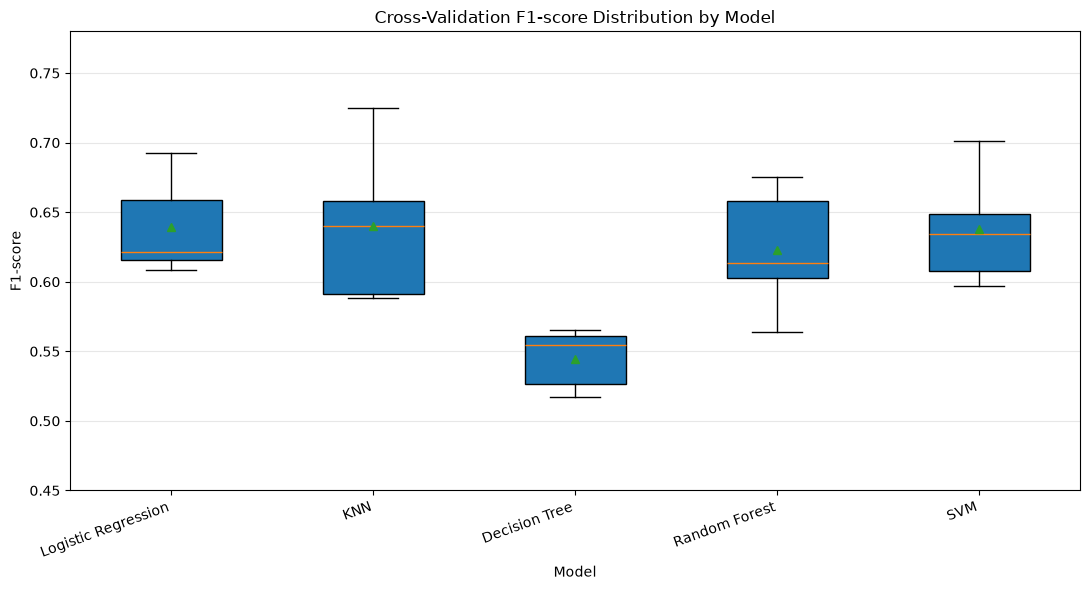

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\diabetes\model_cv_f1_boxplot.png


In [103]:
model_names = list(cv_f1_scores.keys())
score_distributions = [cv_f1_scores[name] for name in model_names]

plt.figure(figsize=(11, 6))
plt.boxplot(
    score_distributions,
    tick_labels=model_names,
    patch_artist=True,
    showmeans=True
)
plt.title("Cross-Validation F1-score Distribution by Model")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0.45, 0.78)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

cv_boxplot_figure = FIGURE_DIR / "model_cv_f1_boxplot.png"
plt.savefig(cv_boxplot_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", cv_boxplot_figure)

#### Phân Tích So Sánh Chéo Kiểm Định

KNN đạt giá trị trung bình CV F1 cao nhất trong năm cấu hình mô hình gốc với 0.6404, tiếp theo gần kề là Logistic Regression với 0.6393 và SVM với 0.6377. Random Forest mặc định đạt 0.6227, trong khi Decision Tree đạt 0.5447. Xếp hạng này khác với xếp hạng giữ lại trước đó, nơi mà Random Forest mặc định có F1-score kiểm tra cao nhất. Sự khác biệt này cho thấy lý do tại sao một kết quả giữ lại duy nhất không nên là cơ sở duy nhất để lựa chọn mô hình.

Trong biểu đồ hộp, đường trung vị đại diện cho kết quả gập giữa, trong khi hộp và các râu cho thấy mức độ phân tán giữa các lần gập. KNN có độ lệch chuẩn lớn nhất (0,0503), cho thấy sự biến động lớn nhất giữa năm mô hình này. Decision Tree có độ lệch chuẩn nhỏ nhất (0,0194), nhưng phân bố thấp liên tục của nó không làm cho mô hình này mạnh nhất. Logistic Regression, SVM, và Random Forest mặc định cho thấy mức độ phân tán trung gian. Vì chỉ có năm lần gập, những quan sát về độ ổn định này mang tính mô tả hơn là khẳng định.

Mô hình sáu đặc trưng được điều chỉnh Random Forest từ Thí nghiệm 2 đạt giá trị CV trung bình F1 là 0,6462 theo cùng một quy trình năm lần gấp. Do đó, nó hơi vượt trội so với năm cấu hình ban đầu, bao gồm KNN, trong khi Thí nghiệm 3 cũng ủng hộ việc giữ lại biểu diễn sáu đặc trưng.

## 17. Lựa chọn mô hình cuối cùng

Cấu hình cuối cùng là một **bộ phân loại Random Forest** sử dụng **sáu đặc trưng đã chọn**. Nó sử dụng `n_estimators=100`, `max_depth=6`, và `random_state=42`. Tiền xử lý được thực hiện trong Pipeline và bao gồm việc điền giá trị trung vị, sau đó là chuẩn hóa.

Lựa chọn cuối cùng ưu tiên bằng chứng đánh giá chéo chỉ dành cho huấn luyện. So sánh giữ lại trước đó được giữ lại như bối cảnh mô tả, nhưng cả bảng đó lẫn kết quả kiểm tra mô hình đã điều chỉnh đều không được sử dụng để sửa đổi cấu hình đã chọn:

- Thí nghiệm 1 cho thấy lựa chọn thuật toán thay đổi đáng kể hiệu suất giữ lại dữ liệu, với Random Forest mặc định là mạnh nhất trong so sánh mô tả đó; quan sát này đã thúc đẩy các thí nghiệm chỉ sử dụng một phần huấn luyện sâu hơn thay vì dùng làm quy tắc lựa chọn cuối cùng. 
- Thí nghiệm 2 đã chọn `max_depth=6` với giá trị trung bình CV huấn luyện F1 cao nhất là 0.6462 trong số các độ sâu được thử nghiệm.
- Thí nghiệm 3 đã chọn sáu đặc trưng vì chúng đạt trung bình CV F1 là 0.6462 so với 0.6243 của cả tám đặc trưng, với độ biến thiên thấp hơn.
- So sánh thuật toán xác thực chéo đã đặt KNN ở vị trí đầu tiên trong số năm cấu hình ban đầu với 0.6404, nhưng Random Forest sáu đặc trưng đã được tinh chỉnh lại nhỉnh hơn một chút ở mức 0.6462.

Khoảng cách so với KNN là nhỏ, vì vậy việc lựa chọn này không nên được hiểu là ưu thế toàn diện. Đây là một lựa chọn có thể tái hiện cho nhiệm vụ này dưới phân chia dữ liệu, chỉ số và thí nghiệm được kiểm soát đã định nghĩa.

In [104]:
from sklearn.metrics import classification_report

final_features = selected_features.copy()
X_train_final = df_clean.loc[X_train.index, final_features]
X_test_final = df_clean.loc[X_test.index, final_features]

final_model = Pipeline([
    ("preprocessor", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        random_state=42
    ))
])

final_model.fit(X_train_final, y_train)
final_pred = final_model.predict(X_test_final)

final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, zero_division=0)
final_recall = recall_score(y_test, final_pred, zero_division=0)
final_f1 = f1_score(y_test, final_pred, zero_division=0)
final_cm = confusion_matrix(y_test, final_pred)

final_metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [final_accuracy, final_precision, final_recall, final_f1]
})

print("Final test metrics:")
print(final_metrics_df.round(4).to_string(index=False))
print("\nFinal Confusion Matrix:")
print(final_cm)
print("\nClassification Report:")
print(classification_report(
    y_test,
    final_pred,
    target_names=["Non-diabetic", "Diabetic"],
    zero_division=0
))

Final test metrics:
   Metric  Score
 Accuracy 0.7468
Precision 0.6667
   Recall 0.5556
 F1-score 0.6061

Final Confusion Matrix:
[[85 15]
 [24 30]]

Classification Report:
              precision    recall  f1-score   support

Non-diabetic       0.78      0.85      0.81       100
    Diabetic       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



### Đánh giá Kiểm tra Cuối cùng

Sau khi cấu hình được chọn bằng cách sử dụng kiểm tra chéo (cross-validation) trong quá trình huấn luyện, Pipeline cuối cùng đã được gắn trên 614 quan sát huấn luyện và đánh giá một lần trên 154 quan sát được giữ lại. Nó đạt Accuracy 0,7468, Precision 0,6667, Recall 0,5556 và F1-score 0,6061. Những giá trị này là đánh giá của hệ thống được chọn, không phải một tiêu chí điều chỉnh khác.

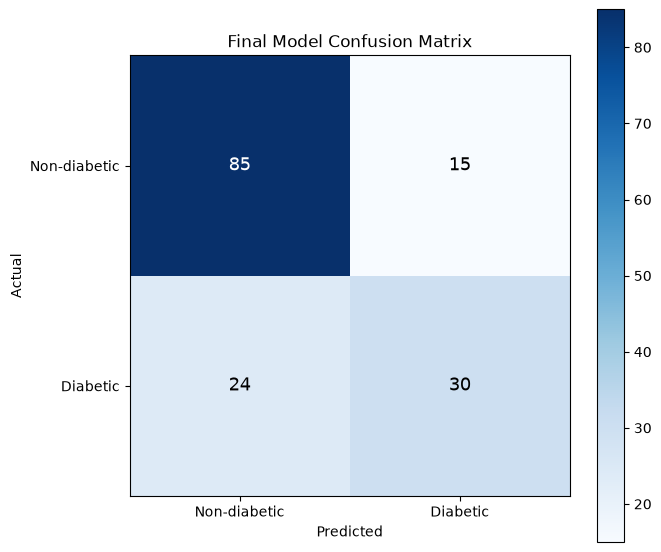

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\diabetes\final_confusion_matrix.png


In [105]:
class_labels = ["Non-diabetic", "Diabetic"]

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(final_cm, cmap="Blues")
fig.colorbar(image, ax=ax)
ax.set_xticks([0, 1], labels=class_labels)
ax.set_yticks([0, 1], labels=class_labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Final Model Confusion Matrix")

threshold = final_cm.max() / 2
for row in range(final_cm.shape[0]):
    for column in range(final_cm.shape[1]):
        value = final_cm[row, column]
        ax.text(
            column,
            row,
            str(value),
            ha="center",
            va="center",
            color="white" if value > threshold else "black",
            fontsize=13
        )

plt.tight_layout()
final_cm_figure = FIGURE_DIR / "final_confusion_matrix.png"
plt.savefig(final_cm_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", final_cm_figure)

### Giải thích Ma trận Nhầm lẫn

Bảng ma trận nhầm lẫn cuối cùng chứa 85 giá trị âm tính thật (TN), 15 giá trị dương tính giả (FP), 24 giá trị âm tính giả (FN) và 30 giá trị dương tính thật (TP). Một giá trị âm tính thật là một quan sát không bị tiểu đường được dự đoán đúng; một giá trị dương tính thật là một quan sát bị tiểu đường được dự đoán đúng. Một giá trị dương tính giả là một quan sát không bị tiểu đường nhưng được dự đoán là bị tiểu đường, trong khi một giá trị âm tính giả là một quan sát bị tiểu đường nhưng được dự đoán là không bị tiểu đường.

Các kết quả âm tính giả xứng đáng được chú ý đặc biệt trong vấn đề học này vì chúng đại diện cho các trường hợp dương tính mà mô hình không thể nhận diện. 24 kết quả âm tính giả này cũng giải thích độ gọi lại cuối cùng là 0,5556. Diễn giải này chỉ hỗ trợ phân tích lỗi cho bài tập: mô hình và các nhãn lớp này chưa được xác thực cho chẩn đoán lâm sàng hoặc ra quyết định.

### Tầm quan trọng của các đặc trưng trong mô hình cuối cùng

Bởi vì Random Forest được chọn tiết lộ `feature_importances_` dựa trên tạp chất, bộ phân loại đã được điều chỉnh có thể cung cấp tóm tắt cụ thể theo mô hình về mức độ mỗi đặc trưng được đại diện đóng góp vào các nhánh cây của nó.

                 Feature  Importance
                 Glucose      0.4017
                     BMI      0.1985
                     Age      0.1344
DiabetesPedigreeFunction      0.1244
             Pregnancies      0.0767
           BloodPressure      0.0643


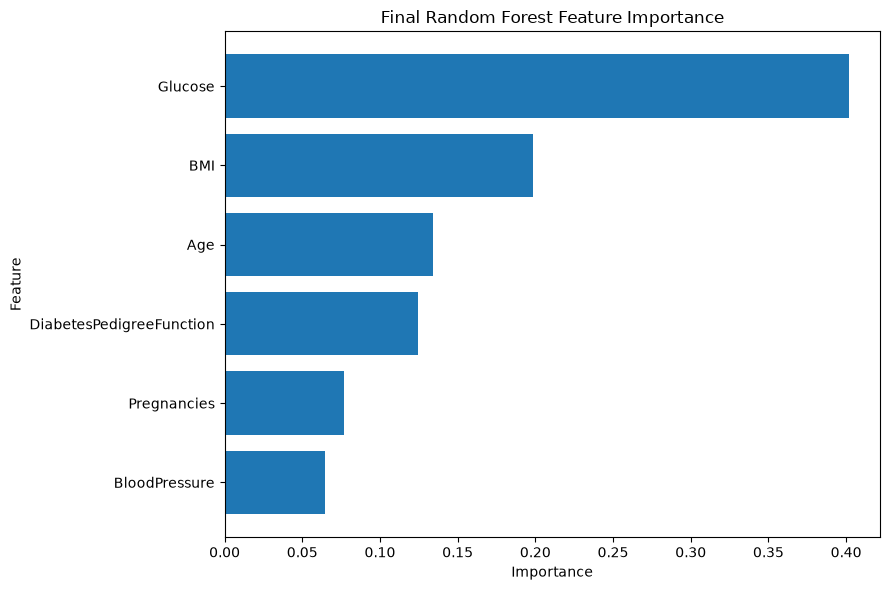

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\diabetes\final_feature_importance.png


In [106]:
final_classifier = final_model.named_steps["model"]

feature_importance_df = (
    pd.DataFrame({
        "Feature": final_features,
        "Importance": final_classifier.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

print(feature_importance_df.round(4).to_string(index=False))

plot_importance_df = feature_importance_df.sort_values("Importance")
plt.figure(figsize=(9, 6))
plt.barh(plot_importance_df["Feature"], plot_importance_df["Importance"])
plt.title("Final Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

feature_importance_figure = FIGURE_DIR / "final_feature_importance.png"
plt.savefig(feature_importance_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", feature_importance_figure)

### Phân tích Tầm quan trọng của Tính năng

Glucose có tầm quan trọng lớn nhất (0.4017), tiếp theo là BMI (0.1985), Age (0.1344), DiabetesPedigreeFunction (0.1244), Pregnancies (0.0767), và BloodPressure (0.0643). Xếp hạng này nhất quán với quan sát trước đó rằng Glucose có tương quan đơn biến mạnh nhất với Outcome, nhưng hai phép đo này không tương đương nhau.

Những giá trị dựa trên tạp chất này mô tả cách Random Forest được huấn luyện sử dụng các đặc trưng trong bộ dữ liệu này. Chúng không thiết lập nguyên nhân, tầm quan trọng lâm sàng, hoặc độ tin cậy cho một quần thể khác. Các đặc trưng có tương quan và hành vi phân tách cây cũng có thể ảnh hưởng đến các giá trị này.

## 18. Trình diễn Hệ thống Thông minh

Ba trường hợp tổng hợp sau đây minh họa cách mà Pipeline đã được huấn luyện đầy đủ chấp nhận đại diện được chọn và trả về dự đoán lớp. Các giá trị được chọn trong phạm vi quan sát của bộ dữ liệu và không được sao chép từ tập thử nghiệm giữ ngoài.

In [107]:
demo_cases = pd.DataFrame([
    {
        "Pregnancies": 1,
        "Glucose": 85,
        "BloodPressure": 66,
        "BMI": 24.0,
        "DiabetesPedigreeFunction": 0.20,
        "Age": 23
    },
    {
        "Pregnancies": 4,
        "Glucose": 125,
        "BloodPressure": 72,
        "BMI": 32.0,
        "DiabetesPedigreeFunction": 0.50,
        "Age": 35
    },
    {
        "Pregnancies": 8,
        "Glucose": 180,
        "BloodPressure": 80,
        "BMI": 38.0,
        "DiabetesPedigreeFunction": 1.20,
        "Age": 55
    }
], index=["Case 1", "Case 2", "Case 3"], columns=final_features)

demo_predictions = final_model.predict(demo_cases)
demo_probabilities = final_model.predict_proba(demo_cases)[:, 1]
prediction_labels = {0: "Non-diabetic", 1: "Diabetic"}

demo_results = pd.DataFrame({
    "Case": demo_cases.index,
    "Predicted Class": demo_predictions,
    "Prediction Label": [prediction_labels[value] for value in demo_predictions],
    "Probability (Class 1)": demo_probabilities
})

print("Demonstration inputs:")
print(demo_cases.to_string())
print("\nDemonstration outputs:")
print(demo_results.round({"Probability (Class 1)": 4}).to_string(index=False))

Demonstration inputs:
        Pregnancies  Glucose  BloodPressure   BMI  DiabetesPedigreeFunction  Age
Case 1            1       85             66  24.0                       0.2   23
Case 2            4      125             72  32.0                       0.5   35
Case 3            8      180             80  38.0                       1.2   55

Demonstration outputs:
  Case  Predicted Class Prediction Label  Probability (Class 1)
Case 1                0     Non-diabetic                 0.0105
Case 2                0     Non-diabetic                 0.4105
Case 3                1         Diabetic                 0.8462


Trường hợp 1 được dự đoán là Không tiểu đường với xác suất lớp-1 là 0,0105, Trường hợp 2 là Không tiểu đường với xác suất 0,4105, và Trường hợp 3 là Tiểu đường với xác suất 0,8462. Các kết quả này chỉ minh họa cơ chế của hệ thống phân loại. Chúng không phải là chẩn đoán lâm sàng, ước tính rủi ro được xác thực để sử dụng trong chăm sóc sức khỏe, hay lời khuyên cho bất kỳ người thực nào.

### Lưu và Tải lại Pipeline Cuối cùng

Toàn bộ Pipeline được lưu trữ để việc điền giá trị trung vị, chuẩn hóa và phân loại vẫn giữ nguyên khi mô hình được một ứng dụng khác tải lên sau đó.

In [108]:
import joblib

MODEL_DIR = PROJECT_ROOT / "models" / "diabetes"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "diabetes_model.joblib"

joblib.dump(final_model, MODEL_PATH)
print("Model saved to:", MODEL_PATH)
print("Model file exists:", MODEL_PATH.exists())

loaded_model = joblib.load(MODEL_PATH)
loaded_demo_predictions = loaded_model.predict(demo_cases)

print("Loaded model demo predictions:", loaded_demo_predictions)
print(
    "Loaded predictions match original predictions:",
    np.array_equal(loaded_demo_predictions, demo_predictions)
)

Model saved to: E:\WINDOW\Project\intelligent-system-assignment-01\models\diabetes\diabetes_model.joblib
Model file exists: True


Loaded model demo predictions: [0 0 1]
Loaded predictions match original predictions: True


## 19. Hệ thống Thông minh Cuối cùng Pipeline

```text
Đầu vào bệnh nhân
      ↓
Biểu diễn đặc trưng (sáu đặc trưng đã chọn)
      ↓
Xử lý phép đo không hợp lệ hoặc bị thiếu
      ↓
Điền thiếu bằng trung vị
      ↓
Chuẩn hóa
      ↓
Random Forest (100 trees, max_depth=6)
      ↓
Dự đoán
      ↓
Ứng dụng Web/Mobile cho người dùng
```

Một đặc trưng thô là một đo lường hoặc thuộc tính có sẵn từ dữ liệu đầu vào gốc của bệnh nhân. Một đặc trưng đại diện là đặc trưng được giữ lại trong vector sáu chiều đã chọn; SkinThickness và Insulin là các đặc trưng trong bộ dữ liệu thô nhưng không phải là một phần của đại diện cuối cùng. Một đầu vào mô hình đã được xử lý trước là giá trị số sau khi áp dụng việc ước lượng giá trị thiếu và chuẩn hóa học được từ dữ liệu huấn luyện. Do đó, đặc trưng thô, đặc trưng đại diện và đầu vào mô hình đã được xử lý trước đề cập đến các giai đoạn khác nhau và không nên được xem là có thể thay thế cho nhau.

Các phép đo bằng không không hợp lệ được chuyển thành giá trị thiếu trong quá trình chuẩn bị bộ dữ liệu. Pipeline được lưu sau đó chỉ học các giá trị trung vị và các tham số chuẩn hóa khi nó được huấn luyện, đảm bảo các phép biến đổi nhất quán cho dữ liệu huấn luyện, kiểm tra, trình diễn và ứng dụng trong tương lai.

## 20. Phản ánh và Hạn chế

1. **Cách biểu diễn ảnh hưởng đến việc học.** Thí nghiệm 3 chỉ thay đổi tập các đặc trưng và tạo ra sự khác biệt về giá trị trung bình và độ biến thiên trong F1-score. Cách biểu diễn với sáu đặc trưng được chọn ở đây mạnh hơn, nhưng kết quả này phụ thuộc vào bộ dữ liệu và quy trình làm việc này.
2. **Việc xử lý giá trị bằng không là quan trọng.** Việc coi các giá trị không hợp lý bằng không như các phép đo sẽ làm méo mó phân phối và tỉ lệ. Chuyển chúng thành giá trị thiếu cho phép nội suy trung vị theo từng lần chia mà không làm mất các quan sát.
3. **Một đường cơ sở cung cấp bối cảnh.** Đường cơ sở của lớp chiếm đa số đạt độ chính xác 64,94% nhưng lớp mắc bệnh tiểu đường đạt F1%, cho thấy độ chính xác tưởng chừng chấp nhận được có thể che giấu một quy tắc dự đoán lớp dương tính không hữu ích.
4. **Accuracy là không đủ.** Precision, hãy nhớ, F1-score, ma trận nhầm lẫn, và báo cáo theo lớp cho thấy các loại lỗi khác nhau dưới tình trạng mất cân bằng lớp.
5. **Các thí nghiệm có kiểm soát cô lập các thay đổi.** Giữ dữ liệu, tiền xử lý, cài đặt mô hình, CV và chỉ số cố định làm cho sự khác biệt do biến độc lập gây ra rõ ràng hơn, mặc dù vẫn tồn tại sự không chắc chắn do lấy mẫu.
6. **Việc lựa chọn thuật toán thay đổi hiệu suất.** Năm thuật toán đã tạo ra các kết quả holdout và CV khác nhau vì chúng học các ranh giới quyết định khác nhau và có hành vi độ chệch-phương sai khác nhau.
7. **Độ sâu của cây kiểm soát độ phức tạp.** Độ sâu 2 bị khớp thiếu trong Thí nghiệm 2, hiệu suất cải thiện đến độ sâu 6, và các cài đặt sâu hơn không cải thiện trung bình CV F1.
8. **Sáu so với tám đặc trưng là thực nghiệm.** Sáu đặc trưng đạt giá trị trung bình CV F1 0.6462 so với 0.6243 cho tám đặc trưng. Các phép đo bổ sung bị thiếu nhiều SkinThickness và Insulin không giúp ích cho mô hình được cấu hình này.
9. **Bộ dữ liệu nhỏ.** Chỉ có 768 quan sát, vì vậy các chỉ số kiểm tra và xếp hạng các fold có thể thay đổi theo cách chia mẫu.
10. **Phạm vi bao phủ dân số bị giới hạn.** Không nên cho rằng bộ dữ liệu đại diện cho mọi nhóm dân số, địa lý hoặc lâm sàng.
11. **Hệ thống mang tính giáo dục.** Nó minh họa quy trình làm việc của một hệ thống thông minh cho một bài tập và không phải là một hệ thống chẩn đoán lâm sàng.
12. **Các chỉ số hiện tại không đủ cho việc triển khai trong chăm sóc sức khỏe.** Việc đánh giá không xác định được độ an toàn, công bằng, hiệu chuẩn, tiện ích trong tương lai hoặc chi phí lỗi chấp nhận được.
13. **Các cải tiến có thể** bao gồm thu thập một tập dữ liệu lớn hơn, thực hiện kiểm định bên ngoài, tiến hành tìm kiếm siêu tham số lồng rộng hơn, đánh giá các chiến lược cân bằng lớp, hiệu chỉnh xác suất, bổ sung các phân tích giải thích phù hợp, và nhận xác thực từ chuyên gia trong lĩnh vực.

## 21. Tính tái lập

Ô lập sau đây ghi lại các phiên bản phần mềm chính được sử dụng cho việc thực thi. Tất cả các cài đặt mô hình phân tách ngẫu nhiên và dựa trên cây đều sử dụng `random_state=42`. Việc phân chia train/test được thực hiện theo tỷ lệ lớp, tiền xử lý được điều chỉnh bên trong Pipelines, và đánh giá chéo lựa chọn mô hình chỉ sử dụng dữ liệu huấn luyện.

In [109]:
import platform
import matplotlib
import sklearn

version_information = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
    "joblib": joblib.__version__
}, name="Version")

print(version_information.to_string())
print("\nReproducibility random_state: 42")

Python          3.12.0
pandas           3.0.5
numpy            2.5.2
matplotlib      3.11.1
scikit-learn     1.9.0
joblib           1.5.3

Reproducibility random_state: 42


# Assignment 02 – Explicit representation and leakage evidence

One observation is one patient record. The deployable raw vector contains six selected columns. Physiologically impossible hidden zeros are converted to missing values by the existing deterministic cleaning logic, after which the fitted training-only median imputer and standard scaler produce a floating-point vector in $R^6$.

**Flow:** original CSV record → selected raw vector → hidden-zero handling → clean vector → median imputation → standard scaling → model input. Here $N$ is the dataset row count, $B$ is a batch size, and $d=6$ is the final feature dimension. Configuration selection remains training-only CV under the existing 80/20 split; the test set is not used for tuning. False negatives are especially important in this educational screening-style task, but the output is not a diagnosis.

In [110]:
from pathlib import Path
import joblib, pandas as pd, numpy as np
root = Path.cwd()
if not (root / 'data').exists(): root = root.parent.parent
df_a2 = pd.read_csv(root / 'data/diabetes/diabetes.csv')
features_a2 = ['Pregnancies','Glucose','BloodPressure','BMI','DiabetesPedigreeFunction','Age']
model_a2 = joblib.load(root / 'models/diabetes/diabetes_model.joblib')
X_a2 = df_a2[features_a2]
raw_record = df_a2.iloc[0]
raw_vector = raw_record[features_a2].to_numpy()
transformed = model_a2.named_steps['preprocessor'].transform(X_a2.iloc[[0]])
print('df.shape =', df_a2.shape, 'X.shape =', X_a2.shape)
print('80/20 shapes =', (614, 6), (154, 6))
print('original record =', raw_record.to_dict())
print('selected raw vector =', raw_vector)
print('transformed shape/dtype/d =', transformed.shape, transformed.dtype, transformed.shape[1])
print('one final numerical vector =', np.asarray(transformed)[0])
print('Leakage audit: preprocessing is inside the Pipeline and fit on training folds only; held-out test is evaluation-only.')

df.shape = (768, 9) X.shape = (768, 6)
80/20 shapes = (614, 6) (154, 6)
original record = {'Pregnancies': 6.0, 'Glucose': 148.0, 'BloodPressure': 72.0, 'SkinThickness': 35.0, 'Insulin': 0.0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50.0, 'Outcome': 1.0}
selected raw vector = [  6.    148.     72.     33.6     0.627  50.   ]
transformed shape/dtype/d = (1, 6) float64 6
one final numerical vector = [ 0.65855832  0.87823751 -0.01141979  0.16892     0.45320462  1.40678576]
Leakage audit: preprocessing is inside the Pipeline and fit on training folds only; held-out test is evaluation-only.
